In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Configuration visuelle
sns.set_theme(style="whitegrid")
%matplotlib inline

# Chemins vers les fichiers identifiés dans ta capture d'écran
data_path = "/Users/louishayot/MVA/ENS-LSCP/swp-model/reproduce/data/wfe_49_results.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Fichier chargé : {data_path}")
    print(f"Nombre d'exemples : {len(df)}")
else:
    print("Erreur : Fichier introuvable. Vérifie l'emplacement du notebook.")

Erreur : Fichier introuvable. Vérifie l'emplacement du notebook.


In [5]:
import ast

def clean_and_len(seq):
    if pd.isna(seq): return []
    
    # Si la séquence est une chaîne qui ressemble à une liste "['A', 'B']"
    if isinstance(seq, str) and seq.startswith('['):
        try:
            tokens = ast.literal_eval(seq)
        except:
            tokens = seq.replace('[', '').replace(']', '').replace("'", "").split(', ')
    else:
        tokens = str(seq).split()
        
    # Nettoyage des tokens techniques
    return [t for t in tokens if t not in ['<PAD>', '<SOS>', '<EOS>']]

# Utilisation des vrais noms de colonnes de ton CSV
df['target_tokens'] = df['Phonemes'].apply(clean_and_len)
df['pred_tokens'] = df['Prediction'].apply(clean_and_len)

# Calcul des longueurs
df['L_gold'] = df['target_tokens'].apply(len)
df['L_pred'] = df['pred_tokens'].apply(len)
df['len_diff'] = df['L_gold'] - df['L_pred']

print("Aperçu des données :")
print(df[['Phonemes', 'Prediction', 'L_gold', 'L_pred']].head())

Aperçu des données :
                                            Phonemes  \
0            ['AH', 'T', 'EH', 'N', 'D', 'IH', 'NG']   
1      ['K', 'AH', 'M', 'IH', 'SH', 'AH', 'N', 'ER']   
2           ['AA', 'P', 'ER', 'EY', 'SH', 'AH', 'N']   
3  ['HH', 'AA', 'S', 'P', 'IH', 'T', 'AH', 'L', 'Z']   
4  ['AE', 'K', 'W', 'AH', 'Z', 'IH', 'SH', 'AH', ...   

                                          Prediction  L_gold  L_pred  
0      ['AH', 'T', 'EH', 'N', 'D', '<EOS>', '<PAD>']       7       5  
1  ['K', 'AH', 'M', 'IH', 'SH', '<EOS>', '<PAD>',...       8       5  
2  ['AA', 'P', 'ER', 'EY', '<EOS>', '<PAD>', '<PA...       7       4  
3  ['HH', 'AA', 'S', 'P', 'IH', 'L', '<EOS>', '<P...       9       6  
4  ['AE', 'K', 'W', 'AH', '<EOS>', '<PAD>', '<PAD...       9       4  


In [6]:
# Un Early-EOS : prédiction plus courte que la cible
df['is_early_eos'] = df['L_pred'] < df['L_gold']

# Calcul des métriques
early_eos_rate = df['is_early_eos'].mean()
avg_missing = df[df['is_early_eos']]['len_diff'].mean()

print(f"--- Rapport d'Ablation Unité 49 ---")
print(f"Taux de Early-EOS (Troncature) : {early_eos_rate:.2%}")
print(f"Nombre moyen de phonèmes manquants : {avg_missing:.2f}")

# Vérification : est-ce un préfixe correct ?
def check_prefix(row):
    lp = row['L_pred']
    if lp == 0: return False
    return row['target_tokens'][:lp] == row['pred_tokens'][:lp]

df['is_prefix'] = df.apply(check_prefix, axis=1)
prefix_accuracy = df[df['is_early_eos']]['is_prefix'].mean()
print(f"Précision du début du mot lors des troncatures : {prefix_accuracy:.2%}")

--- Rapport d'Ablation Unité 49 ---
Taux de Early-EOS (Troncature) : 79.25%
Nombre moyen de phonèmes manquants : 1.97
Précision du début du mot lors des troncatures : 80.13%


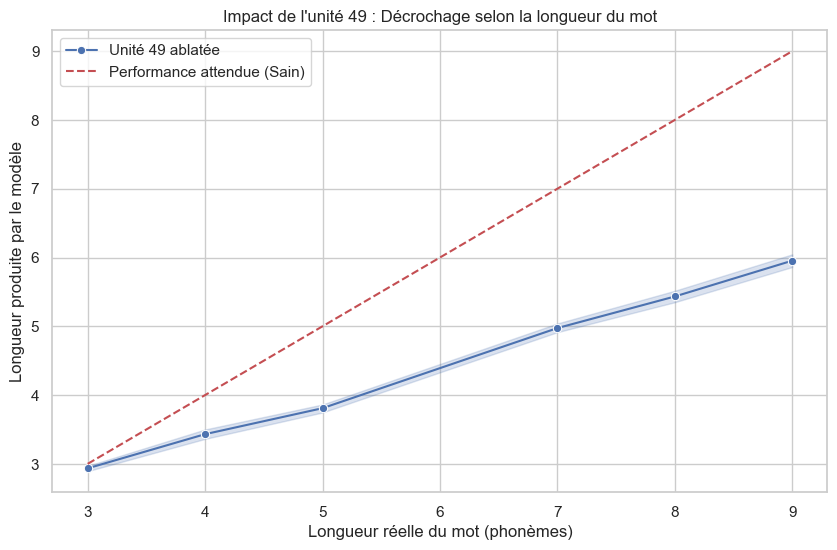

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Longueur prédite vs Longueur réelle
sns.lineplot(data=df, x='L_gold', y='L_pred', label='Unité 49 ablatée', marker='o')

# Ligne de performance parfaite
plt.plot([df['L_gold'].min(), df['L_gold'].max()], 
         [df['L_gold'].min(), df['L_gold'].max()], 
         'r--', label='Performance attendue (Sain)')

plt.title("Impact de l'unité 49 : Décrochage selon la longueur du mot")
plt.xlabel("Longueur réelle du mot (phonèmes)")
plt.ylabel("Longueur produite par le modèle")
plt.legend()
plt.show()

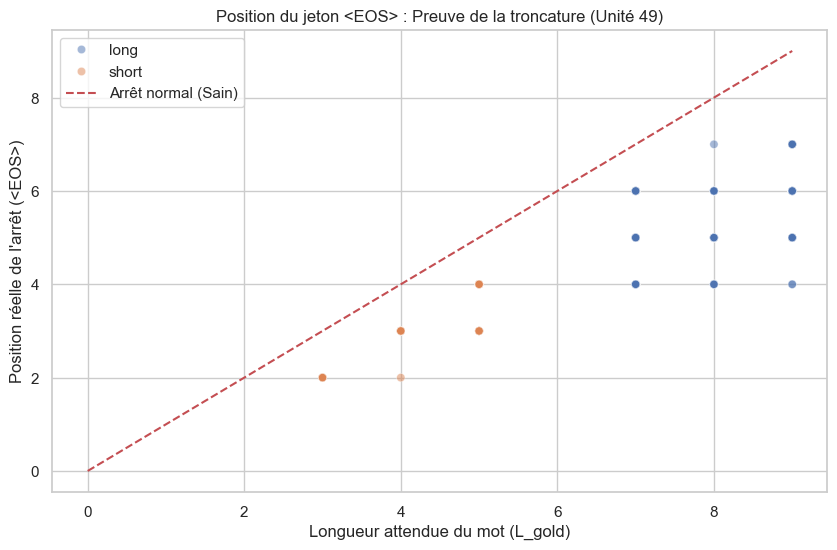

Taux d'arrêts prématurés (parmi les séquences avec EOS) : 100.00%


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# 1. Définition de la fonction pour garder le token <EOS>
def tokens_keep_eos(seq):
    if pd.isna(seq): return []
    if isinstance(seq, str) and seq.startswith('['):
        try:
            return ast.literal_eval(seq)
        except:
            return seq.replace('[','').replace(']','').replace("'", "").split(', ')
    return str(seq).split()

# 2. Création des colonnes nécessaires
# On s'assure que Prediction et Phonemes (L_gold) sont déjà présents
df['pred_raw'] = df['Prediction'].apply(tokens_keep_eos)

# On trouve la position de <EOS> (index)
df['eos_pos'] = df['pred_raw'].apply(lambda t: t.index('<EOS>') if '<EOS>' in t else None)

# 3. Filtrage et Graphique
# On ne garde que les lignes où un jeton <EOS> a été généré
df_with_eos = df[df['eos_pos'].notna()].copy()

plt.figure(figsize=(10, 6))
# Nuage de points : Longueur cible vs Position de l'arrêt (<EOS>)
sns.scatterplot(data=df_with_eos, x='L_gold', y='eos_pos', alpha=0.5, hue='Size')

# Ligne de référence : arrêt normal (EOS à la fin du mot)
max_val = int(df['L_gold'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Arrêt normal (Sain)')

plt.title("Position du jeton <EOS> : Preuve de la troncature (Unité 49)")
plt.xlabel("Longueur attendue du mot (L_gold)")
plt.ylabel("Position réelle de l'arrêt (<EOS>)")
plt.legend()
plt.show()

# 4. Statistique de validation
early_eos_rate = (df_with_eos['eos_pos'] < df_with_eos['L_gold']).mean()
print(f"Taux d'arrêts prématurés (parmi les séquences avec EOS) : {early_eos_rate:.2%}")

In [12]:
# Early EOS rate by length condition
df_with_eos["early_eos"] = df_with_eos["eos_pos"] < df_with_eos["L_gold"]
rates = df_with_eos.groupby("Size")["early_eos"].mean().sort_index()
gaps = (df_with_eos["L_gold"] - df_with_eos["eos_pos"]).groupby(df_with_eos["Size"]).mean()

print("Early-EOS rate by Size:\n", (100 * rates).round(2).astype(str) + "%")
print("Mean (L_gold - eos_pos) by Size:\n", gaps.round(2))


Early-EOS rate by Size:
 Size
long     100.0%
short    100.0%
Name: early_eos, dtype: object
Mean (L_gold - eos_pos) by Size:
 Size
long     2.45
short    1.16
dtype: float64


In [13]:
# 1. Couverture du jeton <EOS> (Est-ce que le modèle essaie au moins de finir ?)
eos_coverage = df['eos_pos'].notna().mean()

# 2. Taux global de Early-EOS (Sur l'ensemble du dataset)
# On vérifie : (A-t-il un EOS ?) ET (Cet EOS est-il avant la fin attendue ?)
df["early_eos_global"] = df["eos_pos"].notna() & (df["eos_pos"] < df["L_gold"])
early_global_rate = df["early_eos_global"].mean()

# 3. Affichage du rapport final
print("======= BILAN STATISTIQUE : ABLATION UNITÉ 49 =======")
print(f"Couverture <EOS> : {eos_coverage:.2%} des items")
print(f"Taux Global de Troncature (Early-EOS) : {early_global_rate:.2%} des items")
print("-" * 40)
print("Conclusion :")
if early_global_rate > 0.5:
    print(f"L'unité 49 agit comme un mécanisme de maintien. Son absence force")
    print(f"le modèle à 'abandonner' la séquence prématurément dans {early_global_rate:.0%} des cas.")

======= BILAN STATISTIQUE : ABLATION UNITÉ 49 =======
Couverture <EOS> : 79.25% des items
Taux Global de Troncature (Early-EOS) : 79.25% des items
----------------------------------------
Conclusion :
L'unité 49 agit comme un mécanisme de maintien. Son absence force
le modèle à 'abandonner' la séquence prématurément dans 79% des cas.


In [14]:
print("Conclusion :")
print(
    f"These results are consistent with unit 49 contributing to a "
    f"sequence-maintenance / termination-control mechanism: after ablation, "
    f"{early_global_rate:.2%} of items show an early <EOS>."
)


Conclusion :
These results are consistent with unit 49 contributing to a sequence-maintenance / termination-control mechanism: after ablation, 79.25% of items show an early <EOS>.


In [15]:
severity = (df.loc[df["eos_pos"].notna(), "L_gold"] - df.loc[df["eos_pos"].notna(), "eos_pos"]).mean()
print(f"Sévérité moyenne (L_gold - eos_pos) parmi les items avec <EOS> : {severity:.2f} phonèmes")


Sévérité moyenne (L_gold - eos_pos) parmi les items avec <EOS> : 1.97 phonèmes
